# Fintrust Digital Bank Week_2


## Risk Review Predictive Model — Initial Development

**Track:**  Data Science  
**Programme:** AnalystLab Africa Experience Lab Internship  
**Project:** FinTrust Financial Intelligence & Digital Banking Support Solution

### Week 2 Objective

The objective is to:
1. Prepare the customer and transaction data for modelling.
2. Perform exploratory data analysis, engineer useful predictive features, develop an initial classification model, evaluate its performance, and document important decisions, limitations, and areas requiring further investigation.

> **Important:** `Risk_Review_Flag` is a synthetic educational target and must not be interpreted as evidence of real fraud or used to make real financial decisions.

## Part A : Data Preparation



In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)

Pandas version: 3.0.5
NumPy version: 2.5.3


### Step 1 & 2: Loading both Datasets.

In [67]:
customer_data = pd.read_csv("Fintrust_Data/customer_data.csv")
transaction_data = pd.read_csv("Fintrust_Data/transaction_data.csv")

print("Customer data loaded successfully.")
print("Transaction data loaded successfully.")

Customer data loaded successfully.
Transaction data loaded successfully.


### Step 3: Joining both Datasets on the "Customer_ID" column

In [68]:
model_data = transaction_data.merge ( 
    customer_data, 
    on= "Customer_ID", 
    how= "left", 
    validate= "many_to_one")

print("Row of the transaction Data Before merge:", len(transaction_data))
print("Row of the model data after merge:", len(model_data))

Row of the transaction Data Before merge: 12000
Row of the model data after merge: 12000


### Step 4: Inspecting Missing Values.

In [69]:
model_data.isnull().sum()

Transaction_ID                0
Customer_ID                   0
Transaction_DateTime          0
Transaction_Type              0
Amount_NGN                    0
Channel                       0
Device_Type                  96
Location                     96
International_Transaction     0
Transaction_Status            0
Risk_Review_Flag              0
Customer_Name                 0
Age                           0
Gender                        0
City                          0
Customer_Segment              0
Account_Type                  0
Tenure_Months                 0
Digital_Engagement_Score      0
Monthly_Income_Band           0
Preferred_Channel             0
Account_Status                0
dtype: int64

In [70]:
missing_summary = pd.DataFrame (

    {
        "missing_values": model_data.isnull().sum(),
        "missing_percentage": ( model_data.isnull().sum() / len(model_data) * 100) .round(2)
    }
)

missing_summary

,missing_values,missing_percentage
Transaction_ID,0,0.0
Customer_ID,0,0.0
Transaction_DateTime,0,0.0
Transaction_Type,0,0.0
Amount_NGN,0,0.0
Channel,0,0.0
Device_Type,96,0.8
Location,96,0.8
International_Transaction,0,0.0
Transaction_Status,0,0.0


In [71]:
missing_summary[
    missing_summary["missing_values"] > 0
]

,missing_values,missing_percentage
Device_Type,96,0.8
Location,96,0.8


In [72]:
both_missing = (
    model_data["Device_Type"].isnull()
    & model_data["Location"].isnull()
)

both_missing.sum()

np.int64(4)

In [73]:
model_data.loc[
    both_missing,
    [
        "Transaction_ID",
        "Channel",
        "Device_Type",
        "Location",
        "Transaction_Type"
    ]
].head(10)

,Transaction_ID,Channel,Device_Type,Location,Transaction_Type
5849,FT-T005850,Mobile App,NaN,NaN,Transfer
8601,FT-T008602,POS,NaN,NaN,Transfer
10781,FT-T010782,Mobile App,NaN,NaN,Card Purchase
11660,FT-T011661,Mobile App,NaN,NaN,Transfer


#### Missing Value Observation

The merged dataset contains missing values in two variables:

Device_Type`: 96 missing records (0.8%) and Location`: 96 missing records (0.8%)



### Step 5: Check for duplicates.

In [74]:
print("Duplicated rows in Model Data:" , model_data.duplicated().sum() )

Duplicated rows in Model Data: 0


In [75]:
print("Duplicated Transaction ID values:", 
      model_data["Transaction_ID"].duplicated().sum()
      )

Duplicated Transaction ID values: 0


In [76]:
print(
    "Repeated Customer_ID values:",
    model_data["Customer_ID"].duplicated().sum()
)

Repeated Customer_ID values: 10500


#### Duplicate Assessment Observation

The modelling dataset contained no duplicate full rows and no duplicate `Transaction_ID` values. This indicates that each transaction record is unique.

Repeated `Customer_ID` values are expected because an individual customer can make multiple transactions. Therefore, repeated customer IDs are not treated as duplicate observations in the transaction-level modelling dataset.

### Step 6: Review Data Types

In [77]:
model_data.dtypes

Transaction_ID                   str
Customer_ID                      str
Transaction_DateTime             str
Transaction_Type                 str
Amount_NGN                   float64
Channel                          str
Device_Type                      str
Location                         str
International_Transaction        str
Transaction_Status               str
Risk_Review_Flag                 str
Customer_Name                    str
Age                            int64
Gender                           str
City                             str
Customer_Segment                 str
Account_Type                     str
Tenure_Months                  int64
Digital_Engagement_Score     float64
Monthly_Income_Band              str
Preferred_Channel                str
Account_Status                   str
dtype: object

In [78]:
model_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Transaction_ID             12000 non-null  str    
 1   Customer_ID                12000 non-null  str    
 2   Transaction_DateTime       12000 non-null  str    
 3   Transaction_Type           12000 non-null  str    
 4   Amount_NGN                 12000 non-null  float64
 5   Channel                    12000 non-null  str    
 6   Device_Type                11904 non-null  str    
 7   Location                   11904 non-null  str    
 8   International_Transaction  12000 non-null  str    
 9   Transaction_Status         12000 non-null  str    
 10  Risk_Review_Flag           12000 non-null  str    
 11  Customer_Name              12000 non-null  str    
 12  Age                        12000 non-null  int64  
 13  Gender                     12000 non-null  str    
 14  C

In [79]:
print(model_data["Transaction_DateTime"].dtype)

str


In [80]:
print(model_data["Transaction_DateTime"].head())

0    1/1/2026 0:00
1    1/1/2026 0:10
2    1/1/2026 0:21
3    1/1/2026 0:32
4    1/1/2026 0:43
Name: Transaction_DateTime, dtype: str


In [81]:
model_data["Transaction_DateTime"] = pd.to_datetime(model_data["Transaction_DateTime"], errors="coerce")

In [82]:
model_data["Transaction_DateTime"].dtypes


model_data["Transaction_DateTime"].head()

0   2026-01-01 00:00:00
1   2026-01-01 00:10:00
2   2026-01-01 00:21:00
3   2026-01-01 00:32:00
4   2026-01-01 00:43:00
Name: Transaction_DateTime, dtype: datetime64[us]

In [83]:
print(
    "Failed date conversions:",
    model_data["Transaction_DateTime"].isnull().sum()
)

Failed date conversions: 0


In [84]:
print("Earliest transaction:", model_data["Transaction_DateTime"].min())
print("Latest transaction:", model_data["Transaction_DateTime"].max())

Earliest transaction: 2026-01-01 00:00:00
Latest transaction: 2026-03-31 23:59:00


### Step 7: Investigate Unusual Values

In [85]:
numeric_columns = [
    "Amount_NGN",
    "Age",
    "Tenure_Months",
    "Digital_Engagement_Score"
]

model_data[numeric_columns].describe()

,Amount_NGN,Age,Tenure_Months,Digital_Engagement_Score
count,12000.000000,12000.000000,12000.000000,12000.000000
mean,46706.446238,41.577167,49.806083,68.192517
std,86028.715234,13.838563,28.074407,17.552866
min,100.170000,18.000000,1.000000,16.700000
25%,2192.220000,29.000000,26.000000,56.100000
50%,10305.935000,42.000000,51.000000,68.300000
75%,48484.475000,53.000000,74.000000,81.400000
max,693454.450000,65.000000,96.000000,100.000000


In [97]:
print(
    "Transactions with amount <= 0:",
    (model_data["Amount_NGN"] <= 0).sum()
)

print(
    "Minimum Amount:",
    model_data["Amount_NGN"].min()
)

print(
    "Maximum Amount:",
    model_data["Amount_NGN"].max()
)

Transactions with amount <= 0: 0
Minimum Amount: 100.17
Maximum Amount: 693454.45


In [98]:
print(
    "Transactions with Digital Engagement Score <= 0:",
    (model_data["Digital_Engagement_Score"] <= 0).sum()
)

print(
    "Minimum digital engagement score:",
    model_data["Digital_Engagement_Score"].min()
)

print(
    "Maximum digital engagement score:",
    model_data["Digital_Engagement_Score"].max()
)

Transactions with Digital Engagement Score <= 0: 0
Minimum digital engagement score: 16.7
Maximum digital engagement score: 100.0


In [101]:
print(
    "Age values <= 0:",
    (model_data["Age"] <= 0).sum()
)

print(
    "Minimum Age:",
    model_data["Age"].min()
)

print(
    "Maximum Age:",
    model_data["Age"].max()
)

Age values <= 0: 0
Minimum Age: 18
Maximum Age: 65


In [103]:
print(
    "Tenure months <= 0:",
    (model_data["Tenure_Months"] <= 0).sum()
)

print(
    "Minimum Tenure months:",
    model_data["Tenure_Months"].min()
)

print(
    "Maximum Tenure months:",
    model_data["Tenure_Months"].max()
)

Tenure months <= 0: 0
Minimum Tenure months: 1
Maximum Tenure months: 96


In [104]:
Q1 = model_data["Amount_NGN"].quantile(0.25)
Q3 = model_data["Amount_NGN"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Q1: 2192.22
Q3: 48484.475
IQR: 46292.255
Lower bound: -67246.16249999999
Upper bound: 117922.85749999998


In [107]:
amount_outliers = model_data[
    (model_data["Amount_NGN"] < lower_bound)
    |
    (model_data["Amount_NGN"] > upper_bound)
]

print(
    "Potential transaction amount outliers:",
    len(amount_outliers)
)

Potential transaction amount outliers: 1474


In [108]:
amount_outliers[
    [
        "Transaction_ID",
        "Amount_NGN",
        "Transaction_Type",
        "Channel",
        "International_Transaction",
        "Risk_Review_Flag"
    ]
].sort_values(
    by="Amount_NGN",
    ascending=False
).head(10)

,Transaction_ID,Amount_NGN,Transaction_Type,Channel,International_Transaction,Risk_Review_Flag
9674,FT-T009675,693454.45,Deposit,USSD,No,Yes
9535,FT-T009536,693006.62,Deposit,Mobile App,No,No
5579,FT-T005580,686958.44,Deposit,POS,No,No
5493,FT-T005494,675336.55,Deposit,Web,No,No
11581,FT-T011582,672369.02,Deposit,Mobile App,No,No
8165,FT-T008166,656198.52,Deposit,Web,No,Yes
4600,FT-T004601,652685.59,Deposit,Web,No,No
5696,FT-T005697,651566.54,Deposit,Mobile App,No,Yes
6407,FT-T006408,650580.09,Deposit,Mobile App,No,No
8087,FT-T008088,643678.47,Deposit,Mobile App,No,No


#### Transaction Amount Outlier Observation

The IQR method identified 1,474 transactions above the standard outlier threshold for `Amount_NGN`.


Therefore, the high transaction amounts were treated as statistical outliers rather than confirmed data errors and were retained for further exploratory analysis and modelling.

In [109]:
model_data["Transaction_Type"].value_counts(dropna=False)

Transaction_Type
Transfer           3549
Card Purchase      3033
Bill Payment       1475
Cash Withdrawal    1430
Deposit            1328
Airtime/Data       1185
Name: count, dtype: int64

In [110]:
model_data["Channel"].value_counts(dropna=False)

Channel
Mobile App    5102
POS           2393
Web           1869
ATM           1747
USSD           889
Name: count, dtype: int64

In [111]:
model_data["Device_Type"].value_counts(dropna=False)

Device_Type
Android         4797
iOS             2920
POS Terminal    1571
Web Browser     1447
ATM Terminal    1169
NaN               96
Name: count, dtype: int64

### For Device Type there are 96 NaN category which corresponds with the missing values that was earlier inspected.

In [112]:
model_data["International_Transaction"].value_counts(dropna=False)

International_Transaction
No     11520
Yes      480
Name: count, dtype: int64

In [113]:
model_data["Transaction_Status"].value_counts(dropna=False)

Transaction_Status
Successful    10856
Failed          630
Reversed        326
Pending         188
Name: count, dtype: int64

### Step 8: Examine the Target Distribution - Risk_Review Flag

In [114]:
target_count = model_data["Risk_Review_Flag"].value_counts()

target_count

Risk_Review_Flag
No     9648
Yes    2352
Name: count, dtype: int64

In [117]:
target_percentage =( 
    model_data["Risk_Review_Flag"].value_counts()
    / len(model_data["Risk_Review_Flag"])
    ) * 100

target_percentage

Risk_Review_Flag
No     80.4
Yes    19.6
Name: count, dtype: float64

In [120]:
target_summary = pd.DataFrame (
    { "Target_Count":  target_count,
     "Target_Percentage":  target_percentage

    }
)

target_summary

,Target_Count,Target_Percentage
Risk_Review_Flag,,
No,9648,80.4
Yes,2352,19.6


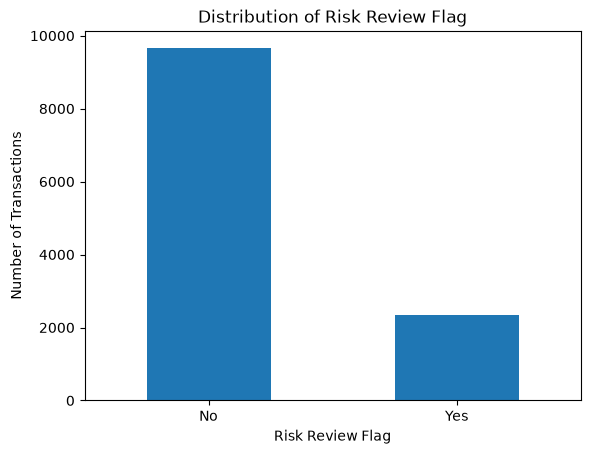

In [122]:
target_count.plot(
    kind="bar"
)

plt.title("Distribution of Risk Review Flag")
plt.xlabel("Risk Review Flag")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)
plt.show()

### Step 9: Identify variables that may be inappropriate for modelling.

In [125]:
model_data.head(10)

,Transaction_ID,Customer_ID,Transaction_DateTime,Transaction_Type,Amount_NGN,Channel,Device_Type,Location,International_Transaction,Transaction_Status,...,Age,Gender,City,Customer_Segment,Account_Type,Tenure_Months,Digital_Engagement_Score,Monthly_Income_Band,Preferred_Channel,Account_Status
0,FT-T000001,FT-C01135,2026-01-01 00:00:00,Card Purchase,5923.80,Mobile App,Android,Enugu,No,Reversed,...,44,Female,Ibadan,Everyday,Current,50,42.9,500k-999k,Mobile App,Active
1,FT-T000002,FT-C00428,2026-01-01 00:10:00,Cash Withdrawal,11681.12,ATM,Android,Kaduna,No,Successful,...,23,Male,Lagos,Everyday,Current,50,95.0,Below 100k,Web,Active
2,FT-T000003,FT-C00469,2026-01-01 00:21:00,Transfer,571.91,ATM,POS Terminal,Kano,No,Successful,...,39,Female,Kaduna,Everyday,Current,53,64.4,100k-249k,Mobile App,Active
3,FT-T000004,FT-C01015,2026-01-01 00:32:00,Deposit,105367.52,Mobile App,Web Browser,Abuja,No,Successful,...,50,Female,Lagos,Everyday,Current,19,61.7,100k-249k,Mobile App,Active
4,FT-T000005,FT-C00870,2026-01-01 00:43:00,Cash Withdrawal,3049.06,Mobile App,POS Terminal,Abuja,No,Successful,...,58,Female,Kano,Everyday,Savings,8,76.5,100k-249k,Mobile App,Active
5,FT-T000006,FT-C00770,2026-01-01 00:54:00,Airtime/Data,175.89,POS,Android,Port Harcourt,No,Successful,...,36,Female,Kano,SME,Premium,33,39.9,500k-999k,Mobile App,Active
6,FT-T000007,FT-C00680,2026-01-01 01:04:00,Airtime/Data,18733.61,Mobile App,Android,Lagos,No,Successful,...,28,Male,Benin City,Premium,Savings,31,79.9,1m+,Mobile App,Active
7,FT-T000008,FT-C00805,2026-01-01 01:15:00,Card Purchase,6702.14,Web,Android,Kaduna,No,Successful,...,19,Female,Lagos,Everyday,Premium,86,85.7,1m+,Mobile App,Dormant
8,FT-T000009,FT-C00886,2026-01-01 01:26:00,Airtime/Data,10503.84,POS,ATM Terminal,Ibadan,No,Successful,...,65,Male,Lagos,Everyday,Current,41,61.4,250k-499k,USSD,Active
9,FT-T000010,FT-C00561,2026-01-01 01:37:00,Airtime/Data,16528.85,Mobile App,ATM Terminal,Benin City,No,Successful,...,49,Female,Abuja,Everyday,Savings,19,77.7,500k-999k,USSD,Dormant


In [127]:
model_data.columns.tolist()

['Transaction_ID',
 'Customer_ID',
 'Transaction_DateTime',
 'Transaction_Type',
 'Amount_NGN',
 'Channel',
 'Device_Type',
 'Location',
 'International_Transaction',
 'Transaction_Status',
 'Risk_Review_Flag',
 'Customer_Name',
 'Age',
 'Gender',
 'City',
 'Customer_Segment',
 'Account_Type',
 'Tenure_Months',
 'Digital_Engagement_Score',
 'Monthly_Income_Band',
 'Preferred_Channel',
 'Account_Status']

In [128]:
columns_to_check = [
    "Transaction_ID",
    "Customer_ID",
    "Customer_Name",
    "Location",
    "City"
]

for column in columns_to_check:
    print(
        column,
        ":",
        model_data[column].nunique(),
        "unique values"
    )

Transaction_ID : 12000 unique values
Customer_ID : 1500 unique values
Customer_Name : 180 unique values
Location : 8 unique values
City : 8 unique values


| Variable               | Concern                                                            | Decision                                                        |
| ---------------------- | ------------------------------------------------------------------ | --------------------------------------------------------------- |
| `Transaction_ID`       | Unique identifier with no behavioural meaning                      | Exclude from predictors; retain for record tracking             |
| `Customer_ID`          | unique Identifier.                    | Exclude directly; retain for customer-level feature engineering |
| `Customer_Name`        | Personal identifier with no useful behavioural meaning             | Exclude                                                         |
| `Risk_Review_Flag`     | This is the prediction target                                      | Use only as target `y`, never as predictor                      |
| `Transaction_DateTime` | Raw timestamp may not be directly useful                           | I will extract time-based features, then exclude raw datetime          |
| `Transaction_Status`   | Possible target leakage depending on when status becomes available | Review timing before deciding whether to include                |
| `Gender`               | Potential fairness/bias concern                                    | Exclude from baseline model or evaluateseparately              |
| `Location`             | May have missing values or many categories                         | Investigate cardinality before final inclusion                  |


### Step 10: Document your data preparation decisions.

1. The Customer and Transaction dataset was joined sucessfully on the "Customer_ID" columnn and the row remained unchanged without losing any records.
2. The "Device_Type" and the "Location" columns had 96 missing values each which acoounts for 0.8% each of the whole data and 1.6% of the dataset combined that was missing. I did not delete the rows because the missing proportion is low and the feature may be still.
3. With regards to duplicated rows, there is no evidence of duplicated rows found.
4. There were repeated entry in the "Customer_ID" column. It was still retained because it is very possible for one customer to make more than one transaction.
5. No duplicates were found in the "Transaction_ID" column.
6. The "Transaction_DateTime"  data type was stored in string. I converted it to a "datetime" format because it cannot be used properly if it is stored as text.
7. Using the IQR rule, 1,474 observations was identified as potential outliers in the "Amount_NGN". I retained them at this stage because an outliers does not necessarily mean it is a data-entry error.

8. The "Customer_Name" was excluded from the dataset because it has no meaningful predictive role. 

9. The "transaction_ID" column is a unique idnetifier and was excluded from the model predictors because it identifies records rather than behaviours.  

10. "Risk_Review_Flag" is the target variable. Including it among predictors would not be appropriate.

11. "Gender" is a Sensitive customer attribute. I plan to exclude it from the baseline model and may evaluate separately. 

# Part B: Exploratory Data Analysis

### Visualization 1: Transaction type vs Risk Review Flag

In [136]:
transaction_type_review_rate = (
    model_data
    .groupby("Transaction_Type")["Risk_Review_Flag"]
    .apply(lambda x: (x == "Yes").mean())
    .sort_values(ascending=False)
    * 100
)

transaction_type_review_rate

Transaction_Type
Transfer           28.486898
Cash Withdrawal    25.314685
Deposit            16.189759
Airtime/Data       15.189873
Card Purchase      13.023409
Bill Payment       12.813559
Name: Risk_Review_Flag, dtype: float64

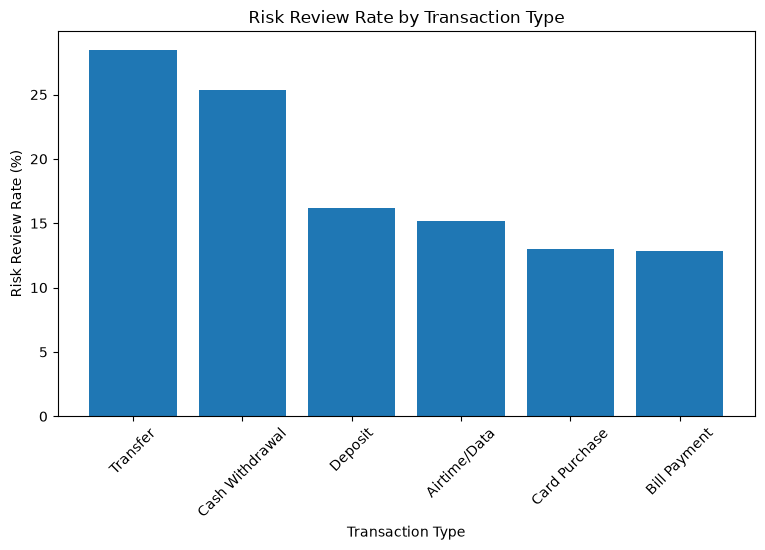

In [137]:
plt.figure(figsize=(9, 5))

plt.bar(
    transaction_type_review_rate.index,
    transaction_type_review_rate.values
)

plt.title("Risk Review Rate by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Risk Review Rate (%)")

plt.xticks(rotation=45)

plt.show()

### Relationship Observed

There is an observable relationship between transaction type and the
risk-review outcome. The proportion of transactions labelled
`Risk_Review_Flag = Yes` differs across transaction types.

Transfer and Cash Withdrawal transactions show higher risk-review rates,
while Card Purchase and Bill Payment show lower rates. This suggests that
`Transaction_Type` may provide useful predictive information for the model.

However, the relationship is associative and does not imply that a
particular transaction type causes a transaction to require risk review.

### Visualization 2: Channel and Risk Review Flag

In [138]:
channel_review_rate = (
    model_data
    .groupby("Channel")["Risk_Review_Flag"]
    .apply(lambda x: (x == "Yes").mean())
    .sort_values(ascending=False)
    * 100
)

channel_review_rate

Channel
Web           21.348315
ATM           21.179164
Mobile App    19.404155
POS           18.345173
USSD          17.322835
Name: Risk_Review_Flag, dtype: float64

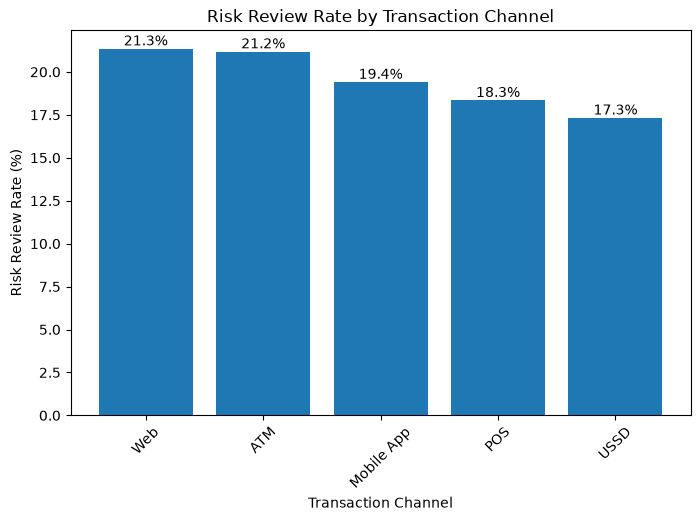

In [139]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    channel_review_rate.index,
    channel_review_rate.values
)

plt.title("Risk Review Rate by Transaction Channel")
plt.xlabel("Transaction Channel")
plt.ylabel("Risk Review Rate (%)")
plt.xticks(rotation=45)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom"
    )

plt.show()

## Visualization 3 — Device Type and Risk Review Flag


In [140]:
model_data["Device_Type"].value_counts(dropna=False)

Device_Type
Android         4797
iOS             2920
POS Terminal    1571
Web Browser     1447
ATM Terminal    1169
NaN               96
Name: count, dtype: int64

In [143]:
device_for_eda = model_data["Device_Type"].fillna("Missing")
device_for_eda.value_counts(dropna=False)

Device_Type
Android         4797
iOS             2920
POS Terminal    1571
Web Browser     1447
ATM Terminal    1169
Missing           96
Name: count, dtype: int64

In [145]:
device_review_rate = (
    model_data
    .assign(Device_EDA=device_for_eda)
    .groupby("Device_EDA")["Risk_Review_Flag"]
    .apply(lambda x: (x == "Yes").mean())
    .sort_values(ascending=False)
    * 100
)

device_review_rate

Device_EDA
ATM Terminal    21.642429
Web Browser     20.110574
Android         19.949969
POS Terminal    18.777849
iOS             18.493151
Missing         16.666667
Name: Risk_Review_Flag, dtype: float64

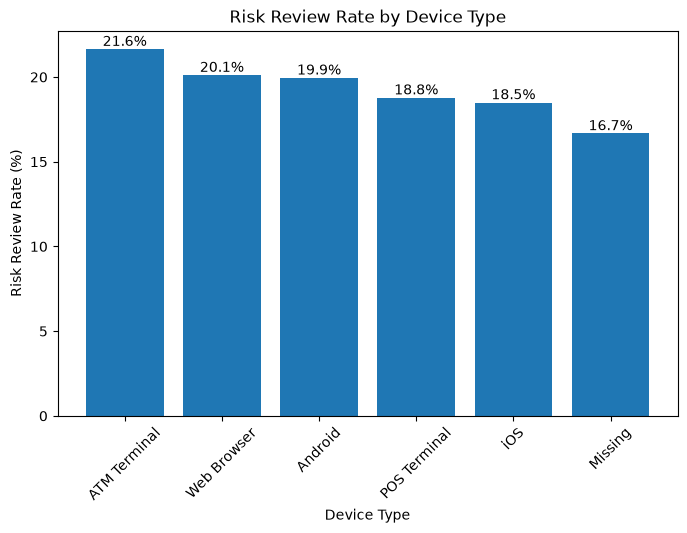

In [146]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    device_review_rate.index,
    device_review_rate.values
)

plt.title("Risk Review Rate by Device Type")
plt.xlabel("Device Type")
plt.ylabel("Risk Review Rate (%)")
plt.xticks(rotation=45)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2, 
        bar.get_height(),
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom"
    )

plt.show()

Risk-review rates were compared across device types.

`ATM Terminal` showed the highest observed proportion of transactions labelled
`Risk_Review_Flag = Yes`, while `Missing` showed the lowest.


## Visualization 4 — Location and Risk Review Flag

In [147]:
print(
    "Number of unique locations:",
    model_data["Location"].nunique()
)

model_data["Location"].value_counts(dropna=False)

Number of unique locations: 8


Location
Ibadan           1550
Kano             1526
Port Harcourt    1520
Enugu            1484
Kaduna           1481
Abuja            1461
Benin City       1451
Lagos            1431
NaN                96
Name: count, dtype: int64

In [148]:
location_for_eda = (
    model_data["Location"]
    .fillna("Missing")
)

In [149]:
location_summary = (
    model_data
    .assign(Location_EDA=location_for_eda)
    .groupby("Location_EDA")
    .agg(
        Transaction_Count=(
            "Transaction_ID",
            "count"
        ),
        Risk_Review_Rate=(
            "Risk_Review_Flag",
            lambda x: (x == "Yes").mean() * 100
        )
    )
    .round(2)
)

location_summary

,Transaction_Count,Risk_Review_Rate
Location_EDA,,
Abuja,1461,18.00
Benin City,1451,20.68
Enugu,1484,18.87
Ibadan,1550,20.58
Kaduna,1481,20.05
Kano,1526,19.66
Lagos,1431,19.50
Missing,96,13.54
Port Harcourt,1520,19.80


In [154]:
location_summary_sorted = (
    location_summary
    .sort_values(
        "Risk_Review_Rate",
        ascending=False
    )
)

location_summary_sorted

,Transaction_Count,Risk_Review_Rate
Location_EDA,,
Benin City,1451,20.68
Ibadan,1550,20.58
Kaduna,1481,20.05
Port Harcourt,1520,19.80
Kano,1526,19.66
Lagos,1431,19.50
Enugu,1484,18.87
Abuja,1461,18.00
Missing,96,13.54


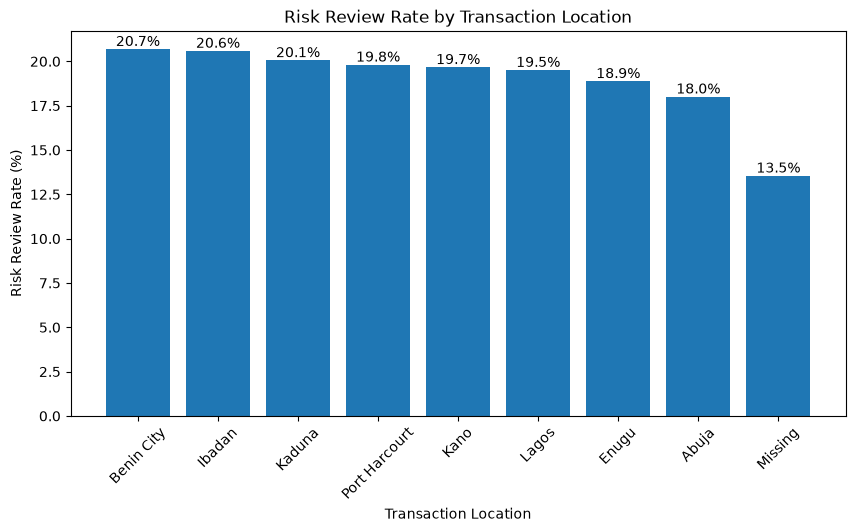

In [155]:
plt.figure(figsize=(10, 5))

bars = plt.bar(
    location_summary_sorted.index,
    location_summary_sorted["Risk_Review_Rate"]
)

plt.title("Risk Review Rate by Transaction Location")
plt.xlabel("Transaction Location")
plt.ylabel("Risk Review Rate (%)")
plt.xticks(rotation=45)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom"
    )

plt.show()

Risk-review rates varied across transaction locations.

`Benin_City` recorded the highest observed review rate, while
`Missing` recorded the lowest among the locations examined.

## Visualization 5 — International Transaction and Risk Review Flag

In [156]:
model_data["International_Transaction"].value_counts(dropna=False)

International_Transaction
No     11520
Yes      480
Name: count, dtype: int64

In [157]:
international_review_rate = (
    model_data
    .groupby("International_Transaction")["Risk_Review_Flag"]
    .apply(lambda x: (x == "Yes").mean())
    .sort_values(ascending=False)
    * 100
)

international_review_rate

International_Transaction
Yes    36.875000
No     18.880208
Name: Risk_Review_Flag, dtype: float64

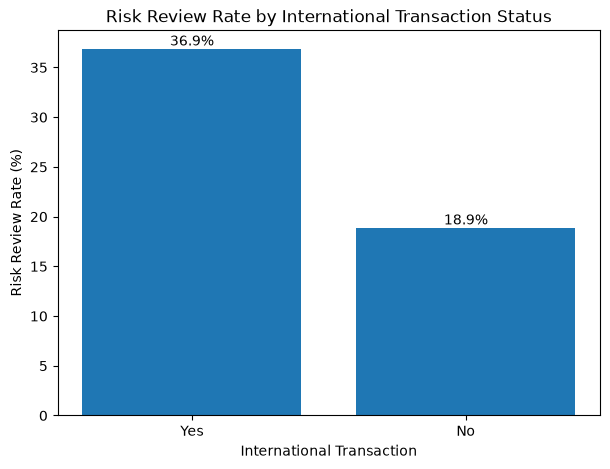

In [158]:
plt.figure(figsize=(7, 5))

bars = plt.bar(
    international_review_rate.index,
    international_review_rate.values
)

plt.title("Risk Review Rate by International Transaction Status")
plt.xlabel("International Transaction")
plt.ylabel("Risk Review Rate (%)")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom"
    )

plt.show()

International and non-international transactions showed different risk-review
rates.

International transactions recorded a higher proportion of
`Risk_Review_Flag = Yes` than non-international transactions.

## Visualization 6 — Transaction Status and Risk Review Flag

In [ ]:
model_data["Transaction_Status"].value_counts(dropna=False)

In [159]:
transaction_status_review_rate = (
    model_data
    .groupby("Transaction_Status")["Risk_Review_Flag"]
    .apply(lambda x: (x == "Yes").mean())
    .sort_values(ascending=False)
    * 100
)

transaction_status_review_rate

Transaction_Status
Failed        26.984127
Successful    19.242815
Reversed      18.404908
Pending       17.553191
Name: Risk_Review_Flag, dtype: float64

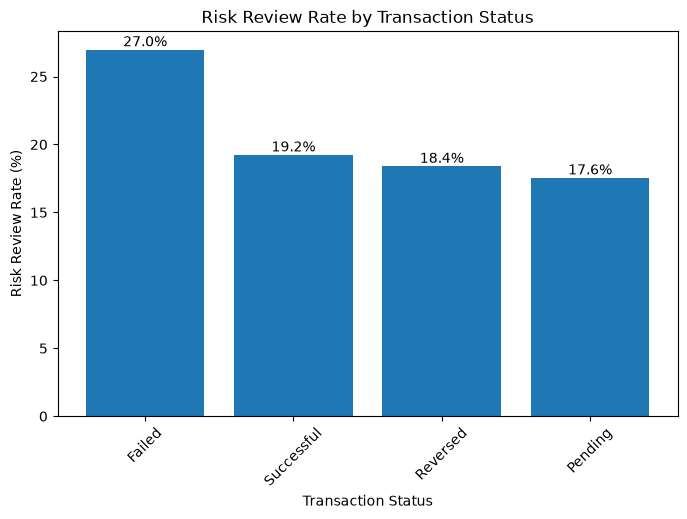

In [160]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    transaction_status_review_rate.index,
    transaction_status_review_rate.values
)

plt.title("Risk Review Rate by Transaction Status")
plt.xlabel("Transaction Status")
plt.ylabel("Risk Review Rate (%)")
plt.xticks(rotation=45)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom"
    )

plt.show()

Risk-review rates varied across transaction statuses.

`Failed` recorded the highest proportion of transactions labelled
`Risk_Review_Flag = Yes`, while `pending` recorded the lowest.

## Visualization 7 — Customer Segment and Risk Review Flag

In [161]:
model_data["Customer_Segment"].value_counts(dropna=False)

Customer_Segment
Everyday    5644
Premium     2361
Student     2289
SME         1706
Name: count, dtype: int64

In [162]:
customer_segment_review_rate = (
    model_data
    .groupby("Customer_Segment")["Risk_Review_Flag"]
    .apply(lambda x: (x == "Yes").mean())
    .sort_values(ascending=False)
    * 100
)

customer_segment_review_rate


Customer_Segment
Premium     20.330368
Student     19.746614
SME         19.402110
Everyday    19.294826
Name: Risk_Review_Flag, dtype: float64

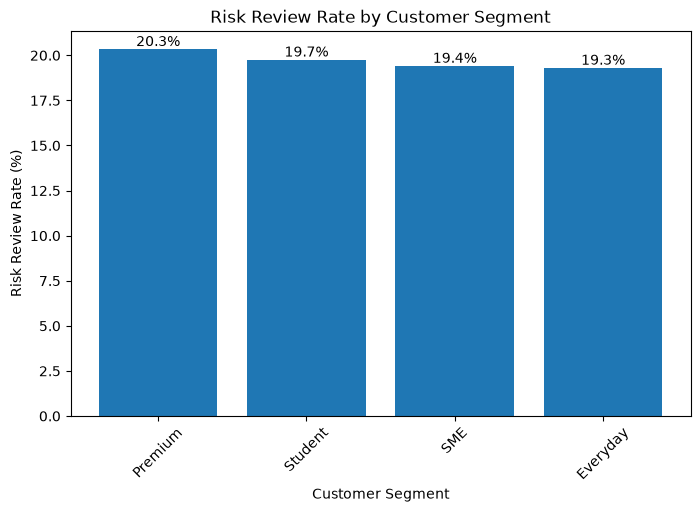

In [163]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    customer_segment_review_rate.index,
    customer_segment_review_rate.values
)

plt.title("Risk Review Rate by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Risk Review Rate (%)")
plt.xticks(rotation=45)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom"
    )


Risk-review rates differed across customer segments.

`Premium` recorded the highest observed proportion of transactions labelled
`Risk_Review_Flag = Yes`, while `Everyday` recorded the lowest.

## Visualization 8 — Account Type and Risk Review Flag

In [164]:
model_data["Account_Type"].value_counts(dropna=False)


Account_Type
Savings    7149
Current    3023
Premium    1828
Name: count, dtype: int64

In [165]:
account_type_review_rate = (
    model_data
    .groupby("Account_Type")["Risk_Review_Flag"]
    .apply(lambda x: (x == "Yes").mean())
    .sort_values(ascending=False)
    * 100
)

account_type_review_rate

Account_Type
Savings    20.142677
Premium    20.076586
Current    18.028449
Name: Risk_Review_Flag, dtype: float64

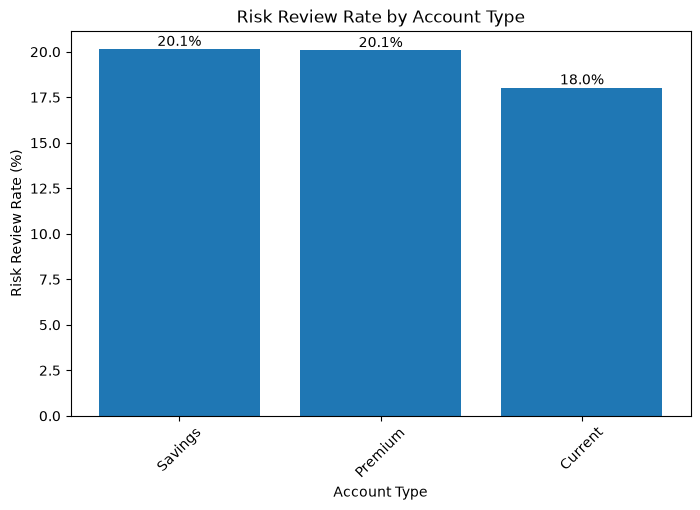

In [166]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    account_type_review_rate.index,
    account_type_review_rate.values
)

plt.title("Risk Review Rate by Account Type")
plt.xlabel("Account Type")
plt.ylabel("Risk Review Rate (%)")
plt.xticks(rotation=45)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom"
    )

plt.show()

`Savings and Premium` recorded the highest observed proportion of transactions labelled
`Risk_Review_Flag = Yes`, while `Currents` recorded the lowest.

This suggests that `Account_Type` may contain useful predictive information
for the model. However, the observed relationship is associative and does not
mean that a particular account type causes a transaction to require risk review.

Digital Engagement Score vs Risk Review Flag### Visualization 9 - 

In [168]:
model_data["Digital_Engagement_Score"].describe()

count    12000.000000
mean        68.192517
std         17.552866
min         16.700000
25%         56.100000
50%         68.300000
75%         81.400000
max        100.000000
Name: Digital_Engagement_Score, dtype: float64

In [169]:
engagement_no = model_data.loc[
    model_data["Risk_Review_Flag"] == "No",
    "Digital_Engagement_Score"
]

engagement_yes = model_data.loc[
    model_data["Risk_Review_Flag"] == "Yes",
    "Digital_Engagement_Score"
]

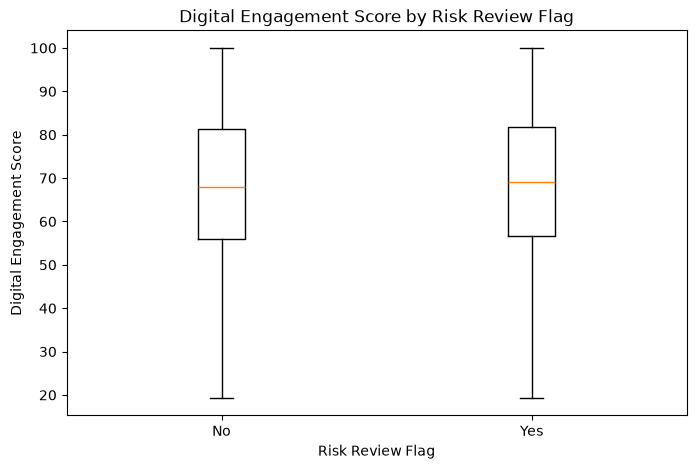

In [170]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    [engagement_no, engagement_yes],
    tick_labels=["No", "Yes"],
    showfliers=False
)

plt.title("Digital Engagement Score by Risk Review Flag")
plt.xlabel("Risk Review Flag")
plt.ylabel("Digital Engagement Score")

plt.show()

igital engagement scores were compared between transactions labelled
`Risk_Review_Flag = Yes` and `Risk_Review_Flag = No`.

The `Yes` group had a similar average and median digital
engagement score compared with the `No` group.

# Part C — Feature Engineering


### 1. Feature 1: Amount_Band from Amount_NGN

In [171]:
model_data["Transaction_DateTime"].dtype

dtype('<M8[us]')

In [172]:
model_data["Amount_Band"] = pd.qcut(
    model_data["Amount_NGN"], 
    q=4,
    labels= ["Low", "Medium", "High", "Very High"] 
)

In [173]:
model_data["Amount_Band"].value_counts()

Amount_Band
Low          3000
Medium       3000
High         3000
Very High    3000
Name: count, dtype: int64

In [174]:
model_data.groupby(
    "Amount_Band",
    observed=True
)["Amount_NGN"].agg(
    ["min", "max", "count"]
)

,min,max,count
Amount_Band,,,
Low,100.17,2189.28,3000
Medium,2193.20,10305.76,3000
High,10306.11,48480.29,3000
Very High,48497.03,693454.45,3000


### Feature 2: Transaction_Hour from Transaction_DateTime

In [175]:
model_data["Transaction_Hour"] = (model_data["Transaction_DateTime"].dt.hour
)

In [178]:
model_data[ "Transaction_Hour"]

0         0
1         0
2         0
3         0
4         0
         ..
11995    23
11996    23
11997    23
11998    23
11999    23
Name: Transaction_Hour, Length: 12000, dtype: int32

In [179]:
print("Minimum hour:", model_data["Transaction_Hour"].min())
print("Maximum hour:", model_data["Transaction_Hour"].max())

Minimum hour: 0
Maximum hour: 23


### Feature 3: Transaction Day of the Week.

In [181]:
model_data["Transaction_Day"] = (
    model_data["Transaction_DateTime"].dt.day_name()
)

In [182]:
model_data[
    ["Transaction_DateTime", "Transaction_Day"]
].head(10)

,Transaction_DateTime,Transaction_Day
0,2026-01-01 00:00:00,Thursday
1,2026-01-01 00:10:00,Thursday
2,2026-01-01 00:21:00,Thursday
3,2026-01-01 00:32:00,Thursday
4,2026-01-01 00:43:00,Thursday
5,2026-01-01 00:54:00,Thursday
6,2026-01-01 01:04:00,Thursday
7,2026-01-01 01:15:00,Thursday
8,2026-01-01 01:26:00,Thursday
9,2026-01-01 01:37:00,Thursday


### Feature 4 — Customer Tenure

In [183]:
model_data["Tenure_Months"].describe()

count    12000.000000
mean        49.806083
std         28.074407
min          1.000000
25%         26.000000
50%         51.000000
75%         74.000000
max         96.000000
Name: Tenure_Months, dtype: float64

In [184]:
model_data["Tenure_Category"] = pd.cut(
    model_data["Tenure_Months"],
    bins=[0, 12, 36, 60, float("inf")],
    labels=[
        "New",
        "Developing",
        "Established",
        "Long-term"
    ]
)

In [185]:
model_data[
    ["Tenure_Months", "Tenure_Category"]
].head(10)

,Tenure_Months,Tenure_Category
0,50,Established
1,50,Established
2,53,Established
3,19,Developing
4,8,New
5,33,Developing
6,31,Developing
7,86,Long-term
8,41,Established
9,19,Developing


### Feature %: Digital Engagement Category

In [186]:
model_data["Digital_Engagement_Score"].describe()

count    12000.000000
mean        68.192517
std         17.552866
min         16.700000
25%         56.100000
50%         68.300000
75%         81.400000
max        100.000000
Name: Digital_Engagement_Score, dtype: float64

In [187]:
model_data["Engagement_Category"] = pd.qcut(
    model_data["Digital_Engagement_Score"],
    q=3,
    labels=["Low", "Medium", "High"]
)

In [ ]:
model_data[
    [
        "Digital_Engagement_Score",
        "Engagement_Category"
    ]
].head(10)

In [188]:
model_data.groupby(
    "Engagement_Category",
    observed=True
)["Digital_Engagement_Score"].agg(
    ["min", "max", "count"]
)

,min,max,count
Engagement_Category,,,
Low,16.7,60.0,4022
Medium,60.1,77.2,3991
High,77.3,100.0,3987


### Feature 6 — International Transaction Indicator

In [190]:
model_data["International_Transaction"].value_counts(dropna=False)

International_Transaction
No     11520
Yes      480
Name: count, dtype: int64

In [191]:
model_data["International_Flag"] = (
    model_data["International_Transaction"]
    .map({
        "No": 0,
        "Yes": 1
    })
)

### Feature 7 — Customer Transaction Count

In [192]:
model_data["Customer_ID"].value_counts().head(10)

Customer_ID
FT-C01296    20
FT-C00965    19
FT-C01487    18
FT-C00209    18
FT-C00357    18
FT-C00351    18
FT-C00816    17
FT-C01037    17
FT-C01423    17
FT-C00959    17
Name: count, dtype: int64

In [193]:
model_data["Customer_Transaction_Count"] = (
    model_data
    .groupby("Customer_ID")["Transaction_ID"]
    .transform("count")
)

In [194]:
model_data.groupby("Customer_ID")["Transaction_ID"].count()

Customer_ID
FT-C00001     7
FT-C00002     5
FT-C00003     2
FT-C00004     9
FT-C00005     7
             ..
FT-C01496     8
FT-C01497     4
FT-C01498    10
FT-C01499     7
FT-C01500    11
Name: Transaction_ID, Length: 1500, dtype: int64

In [195]:
model_data[
    [
        "Customer_ID",
        "Transaction_ID",
        "Customer_Transaction_Count"
    ]
].head(15)

,Customer_ID,Transaction_ID,Customer_Transaction_Count
0,FT-C01135,FT-T000001,6
1,FT-C00428,FT-T000002,6
2,FT-C00469,FT-T000003,9
3,FT-C01015,FT-T000004,12
4,FT-C00870,FT-T000005,11
5,FT-C00770,FT-T000006,11
6,FT-C00680,FT-T000007,7
7,FT-C00805,FT-T000008,7
8,FT-C00886,FT-T000009,10
9,FT-C00561,FT-T000010,11


### Feature 8 — Transaction Frequency

In [ ]:
frequency_data = model_data.sort_values(
    ["Customer_ID", "Transaction_DateTime"]
).copy()

In [202]:
model_data["Hours_Since_Previous_Transaction"] = (
    frequency_data["Hours_Since_Previous_Transaction"]
    .reindex(model_data.index)
)

In [204]:
frequency_data["Hours_Since_Previous_Transaction"] = (
    frequency_data
    .groupby("Customer_ID")["Transaction_DateTime"]
    .diff()
    .dt.total_seconds()
    / 3600
)

In [205]:
model_data[
    "Hours_Since_Previous_Transaction"
].isnull().sum()

np.int64(1500)

In [206]:
model_data[
    "Hours_Since_Previous_Transaction"
].describe()

count    10500.000000
mean       231.603514
std        222.663182
min          0.166667
25%         67.316667
50%        164.716667
75%        324.020833
max       1778.900000
Name: Hours_Since_Previous_Transaction, dtype: float64

| Feature | How It Was Created | Why It May Matter |
|---|---|---|
| `Amount_Band` | Transaction amounts were grouped into four levels: Low, Medium, High, and Very High. | This helps the model see whether smaller and larger transactions behave differently. |
| `Transaction_Hour` | The hour was taken from `Transaction_DateTime`, giving values from 0 to 23. | Transactions made at different times of the day may show different behaviour. |
| `Transaction_Day` | The day of the week was taken from `Transaction_DateTime`, such as Monday, Tuesday, etc. | Transaction behaviour may change depending on the day of the week. |
| `Tenure_Category` | `Tenure_Months` was grouped into New, Developing, Established, and Long-term customers. | Customers who have been with the bank for different lengths of time may have different transaction patterns. |
| `Engagement_Category` | `Digital_Engagement_Score` was grouped into Low, Medium, and High engagement. | Customers with different levels of digital activity may use banking services differently. |
| `International_Flag` | `International_Transaction` was changed from Yes/No into numbers: Yes = 1 and No = 0. | International and local transactions may have different patterns, so this may help prediction. |
| `Customer_Transaction_Count` | The total number of transactions belonging to each customer was counted. | It gives an idea of how active each customer is. More active and less active customers may behave differently. |
| `Hours_Since_Previous_Transaction` | The time between a customer's current transaction and their previous transaction was calculated in hours. | It shows how frequently the customer is transacting and can identify periods of very frequent or very spread-out activity. |

## Part D — Baseline Model Development

### Step 1 — Prepare the Target Variable

The target variable is `Risk_Review_Flag`, which indicates whether a
transaction requires risk review.

For modelling purposes, the target was converted into a numerical binary
variable:

- No = 0
- Yes = 1

The target distribution was checked before model training because the dataset
contains more No cases than Yes cases. This class imbalance will be considered
when splitting and evaluating the model.

### Creating " Y"

In [210]:
y = model_data["Risk_Review_Flag"].map({
    "No": 0,
    "Yes": 1
})
y.value_counts()



Risk_Review_Flag
0    9648
1    2352
Name: count, dtype: int64

In [211]:
(y.value_counts(normalize=True) * 100).round(2)


Risk_Review_Flag
0    80.4
1    19.6
Name: proportion, dtype: float64

### Creating X

In [212]:
model_data.columns.tolist()

['Transaction_ID',
 'Customer_ID',
 'Transaction_DateTime',
 'Transaction_Type',
 'Amount_NGN',
 'Channel',
 'Device_Type',
 'Location',
 'International_Transaction',
 'Transaction_Status',
 'Risk_Review_Flag',
 'Customer_Name',
 'Age',
 'Gender',
 'City',
 'Customer_Segment',
 'Account_Type',
 'Tenure_Months',
 'Digital_Engagement_Score',
 'Monthly_Income_Band',
 'Preferred_Channel',
 'Account_Status',
 'Amount_Band',
 'Transaction_Hour',
 'Transaction_Day',
 'Tenure_Category',
 'Engagement_Category',
 'International_Flag',
 'Customer_Transaction_Count',
 'Hours_Since_Previous_Transaction']

In [215]:
model_features = [
    "Amount_NGN",
    "Transaction_Type",
    "Channel",
    "Device_Type",
    "Location",
    "Age",
    "Customer_Segment",
    "Account_Type",
    "Tenure_Months",
    "Digital_Engagement_Score",
    "Monthly_Income_Band",
    "Preferred_Channel",
    "Transaction_Hour",
    "Transaction_Day",
    "International_Flag",
    "Customer_Transaction_Count",
    "Hours_Since_Previous_Transaction"
]

In [217]:
X = model_data[model_features].copy()

X.head()

,Amount_NGN,Transaction_Type,Channel,Device_Type,Location,Age,Customer_Segment,Account_Type,Tenure_Months,Digital_Engagement_Score,Monthly_Income_Band,Preferred_Channel,Transaction_Hour,Transaction_Day,International_Flag,Customer_Transaction_Count,Hours_Since_Previous_Transaction
0,5923.80,Card Purchase,Mobile App,Android,Enugu,44,Everyday,Current,50,42.9,500k-999k,Mobile App,0,Thursday,0,6,NaN
1,11681.12,Cash Withdrawal,ATM,Android,Kaduna,23,Everyday,Current,50,95.0,Below 100k,Web,0,Thursday,0,6,NaN
2,571.91,Transfer,ATM,POS Terminal,Kano,39,Everyday,Current,53,64.4,100k-249k,Mobile App,0,Thursday,0,9,NaN
3,105367.52,Deposit,Mobile App,Web Browser,Abuja,50,Everyday,Current,19,61.7,100k-249k,Mobile App,0,Thursday,0,12,NaN
4,3049.06,Cash Withdrawal,Mobile App,POS Terminal,Abuja,58,Everyday,Savings,8,76.5,100k-249k,Mobile App,0,Thursday,0,11,NaN


In [218]:
X.shape

(12000, 17)

In [219]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (12000, 17)
y shape: (12000,)


In [220]:
X.isnull().sum()

Amount_NGN                             0
Transaction_Type                       0
Channel                                0
Device_Type                           96
Location                              96
Age                                    0
Customer_Segment                       0
Account_Type                           0
Tenure_Months                          0
Digital_Engagement_Score               0
Monthly_Income_Band                    0
Preferred_Channel                      0
Transaction_Hour                       0
Transaction_Day                        0
International_Flag                     0
Customer_Transaction_Count             0
Hours_Since_Previous_Transaction    1500
dtype: int64

### Predictor Variables (X)

The predictor matrix `X` was created using selected transaction, customer,
temporal, and behavioural variables.

Identifier variables such as `Transaction_ID`, `Customer_ID`, and
`Customer_Name` were excluded because they identify records rather than
represent meaningful predictive characteristics.

`Risk_Review_Flag` was excluded because it is the prediction target.

The raw Transaction_DateTime field was excluded because relevant temporal features such as transaction hour and transaction day had already been derived.

`Transaction_Status` was excluded from the baseline model because its timing
relative to the risk-review decision is unclear and it may therefore introduce
target leakage.

In [222]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [224]:
from sklearn.model_selection import train_test_split

In [225]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [226]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (9600, 17)
X_test shape: (2400, 17)
y_train shape: (9600,)
y_test shape: (2400,)


In [227]:
print("Training target distribution:")
print(
    (y_train.value_counts(normalize=True) * 100).round(2)
)

print("\nTest target distribution:")
print(
    (y_test.value_counts(normalize=True) * 100).round(2)
)

Training target distribution:
Risk_Review_Flag
0    80.4
1    19.6
Name: proportion, dtype: float64

Test target distribution:
Risk_Review_Flag
0    80.42
1    19.58
Name: proportion, dtype: float64


### Train-Test Split

The modelling dataset was divided into training and testing subsets using an
80:20 split.

The training set contains 80% of the observations and is used to train the
baseline model. The remaining 20% is reserved for evaluating how well the
model performs on unseen transactions.

Stratified sampling was used because the target variable is imbalanced,
with approximately 80.4% No cases and 19.6% Yes cases. Stratification helps
maintain approximately the same target distribution in both the training and
test sets.

A fixed random state of 42 was used to make the split reproducible.

In [228]:
numeric_features = [
    "Amount_NGN",
    "Age",
    "Tenure_Months",
    "Digital_Engagement_Score",
    "Transaction_Hour",
    "International_Flag",
    "Customer_Transaction_Count",
    "Hours_Since_Previous_Transaction"
]

In [230]:
categorical_features = [
    "Transaction_Type",
    "Channel",
    "Device_Type",
    "Location",
    "Customer_Segment",
    "Account_Type",
    "Monthly_Income_Band",
    "Preferred_Channel",
    "Transaction_Day"
]

In [231]:
print("Number of numerical features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))
print("Total features:", len(numeric_features) + len(categorical_features))

Number of numerical features: 8
Number of categorical features: 9
Total features: 17


In [ ]:
X_train.isnull().sum()


Amount_NGN                            0
Transaction_Type                      0
Channel                               0
Device_Type                          12
Location                             24
Age                                   0
Customer_Segment                      0
Account_Type                          0
Tenure_Months                         0
Digital_Engagement_Score              0
Monthly_Income_Band                   0
Preferred_Channel                     0
Transaction_Hour                      0
Transaction_Day                       0
International_Flag                    0
Customer_Transaction_Count            0
Hours_Since_Previous_Transaction    312
dtype: int64

In [233]:
X_test.isnull().sum()

Amount_NGN                            0
Transaction_Type                      0
Channel                               0
Device_Type                          12
Location                             24
Age                                   0
Customer_Segment                      0
Account_Type                          0
Tenure_Months                         0
Digital_Engagement_Score              0
Monthly_Income_Band                   0
Preferred_Channel                     0
Transaction_Hour                      0
Transaction_Day                       0
International_Flag                    0
Customer_Transaction_Count            0
Hours_Since_Previous_Transaction    312
dtype: int64

In [ ]:
from sklearn.impute import SimpleImputer

In [234]:
from sklearn.impute import SimpleImputer

numeric_imputer = SimpleImputer(
    strategy="median"
)

categorical_imputer = SimpleImputer(
    strategy="constant",
    fill_value="Missing"
)

In [235]:
from sklearn.preprocessing import StandardScaler

In [237]:
from sklearn.pipeline import Pipeline

In [238]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

In [239]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

In [240]:
from sklearn.preprocessing import OneHotEncoder

In [262]:
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="constant",
                fill_value="Missing"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [263]:
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="constant",
                fill_value="Missing"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [264]:
from sklearn.compose import ColumnTransformer

In [265]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [266]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [267]:
from sklearn.linear_model import LogisticRegression

In [268]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [269]:
max_iter=1000

In [279]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

### Baseline Classifier

Logistic Regression was selected as the baseline classification algorithm.

The model is appropriate because `Risk_Review_Flag` is a binary target with
two possible outcomes: No and Yes.

Logistic Regression estimates the probability that a transaction belongs to
the positive class (`Risk_Review_Flag = Yes`) based on the predictor variables.

A maximum of 1,000 iterations was allowed to provide sufficient opportunity
for the model-training process to converge.

### Train the model

In [284]:
baseline_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            logistic_model
        )
    ]
)

In [285]:
baseline_model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](17,)","['Amount_NGN','Transaction_Type','Channel',...,'International_Flag', 'Customer_Transaction_Count','Hours_Since_Previous_Transaction']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,17
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (def

### Step 11 — Generate Predictions

In [286]:
y_pred = baseline_model.predict(X_test)

In [287]:
y_pred[:20]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [288]:
prediction_check = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

prediction_check.head(20)

,Actual,Predicted
0,0,0
1,0,0
2,0,0
3,0,0
4,1,0
5,0,0
6,1,0
7,0,0
8,0,0
9,0,0


In [289]:
pd.Series(y_pred).value_counts()

0    2364
1      36
Name: count, dtype: int64

### Generate Probability

In [290]:
y_pred_proba = baseline_model.predict_proba(X_test)[:, 1]

In [293]:
prediction_check["Probability_Yes"] = y_pred_proba

prediction_check.head(20)

,Actual,Predicted,Probability_Yes
0,0,0,0.112372
1,0,0,0.218351
2,0,0,0.241153
3,0,0,0.177551
4,1,0,0.405262
5,0,0,0.100507
6,1,0,0.244596
7,0,0,0.188051
8,0,0,0.090726
9,0,0,0.296069


### Prediction Generation

The trained baseline model was applied to the unseen test dataset to generate
predicted risk-review classes.

Class predictions were produced as 0 for No and 1 for Yes. Predicted
probabilities for the positive class were also generated for use in later
performance evaluation, including ROC-AUC analysis.

# Part E — Model Evaluation

The baseline Logistic Regression model was evaluated using the unseen test
dataset.

Because the target variable is imbalanced, model performance was assessed
using multiple metrics rather than accuracy alone. These include accuracy,
precision, recall, F1 score, confusion matrix, and ROC-AUC.

In [294]:
from sklearn.metrics import accuracy_score

In [295]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

accuracy

0.8016666666666666

In [296]:
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 80.17%


In [297]:
majority_baseline_accuracy = (
    y_test.value_counts(normalize=True).max()
)

print(
    f"Model Accuracy: {accuracy * 100:.2f}%"
)

print(
    f"Majority-Class Baseline Accuracy: "
    f"{majority_baseline_accuracy * 100:.2f}%"
)

Model Accuracy: 80.17%
Majority-Class Baseline Accuracy: 80.42%


### Accuracy

The model achieved an accuracy of 80.17%.

However, approximately 80.4% of the test observations belong to the majority
class (`Risk_Review_Flag = No`). Therefore, a model predicting No for every
transaction would already achieve approximately 80.4% accuracy.

Accuracy alone is therefore insufficient for assessing model performance,
and additional metrics such as precision, recall, F1 score, confusion matrix,
and ROC-AUC were examined.

### Step 2 — Precision

In [298]:
from sklearn.metrics import precision_score

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

print(f"Precision: {precision * 100:.2f}%")

Precision: 41.67%


### Precision


It is calculated as the number of correctly predicted positive cases divided
by all transactions predicted as positive.

A higher precision indicates that fewer transactions predicted as requiring
risk review were actually negative cases.

### Step 3 — Recall

In [299]:
from sklearn.metrics import recall_score

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

print(f"Recall: {recall * 100:.2f}%")

Recall: 3.19%


Recall measures the proportion of actual positive cases that the model
successfully identifies.

It is calculated as the number of correctly predicted positive cases divided
by the total number of actual positive cases.

A higher recall indicates that the model misses fewer transactions that were
actually labelled `Risk_Review_Flag = Yes`.

###  Step 4 — F1 Score

In [301]:
from sklearn.metrics import f1_score

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

print(f"F1 Score: {f1 * 100:.2f}%")

F1 Score: 5.93%


An F1 score of 5.93% is very low, but that does not automatically mean your code or model is wrong. 

The F1 score combines precision and recall into a single metric.

It is useful when the target classes are imbalanced because it considers both
the model's ability to make correct positive predictions and its ability to
identify actual positive cases.

A higher F1 score indicates a better balance between precision and recall.



### Step 5 — Confusion Matrix

In [302]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

cm

array([[1909,   21],
       [ 455,   15]])

In [303]:
print("Predicted classes:")
print(pd.Series(y_pred).value_counts())

print("\nActual classes:")
print(y_test.value_counts())

Predicted classes:
0    2364
1      36
Name: count, dtype: int64

Actual classes:
Risk_Review_Flag
0    1930
1     470
Name: count, dtype: int64


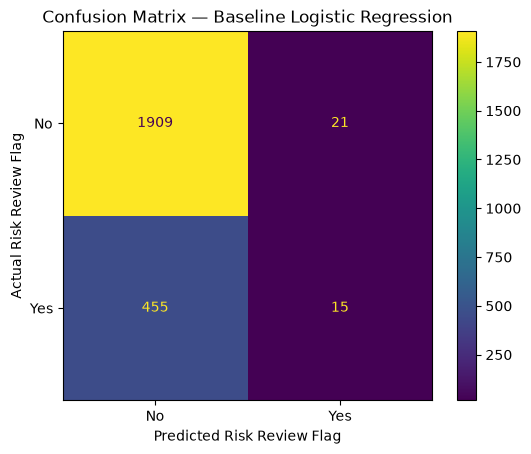

In [310]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No", "Yes"]
)

disp.plot()

plt.title("Confusion Matrix — Baseline Logistic Regression")
plt.xlabel("Predicted Risk Review Flag")
plt.ylabel("Actual Risk Review Flag")

plt.show()

### Confusion Matrix Interpretation

The confusion matrix shows that the baseline Logistic Regression model
correctly classified a large majority of the negative (`No`) transactions
but performed poorly in identifying positive (`Yes`) transactions.

The model correctly classified approximately 1,909 negative transactions
and only 15 positive transactions. It incorrectly classified approximately
455 actual positive transactions as negative, resulting in a large number
of false negatives.

This explains the model's very low recall of 3.19% and F1 score of 5.93%.
The results indicate that the baseline model strongly favours the majority
`No` class and has difficulty identifying transactions labelled for risk
review.

In [311]:
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall: {recall * 100:.2f}%")
print(f"F1 Score: {f1 * 100:.2f}%")

Precision: 41.67%
Recall: 3.19%
F1 Score: 5.93%


The baseline Logistic Regression achieved an F1 score of 5.93%, indicating poor balance between precision and recall for the positive (Yes) class. Further examination of the confusion matrix, precision, and recall is required to determine whether the low score is mainly caused by missed positive cases, false positive predictions, or both.

### Step 6 — ROC-AUC.

In [312]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(
    y_test,
    y_pred_proba
)

print(f"ROC-AUC: {roc_auc:.3f}")

ROC-AUC: 0.668


In [313]:
from sklearn.metrics import roc_curve

In [314]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_pred_proba
)

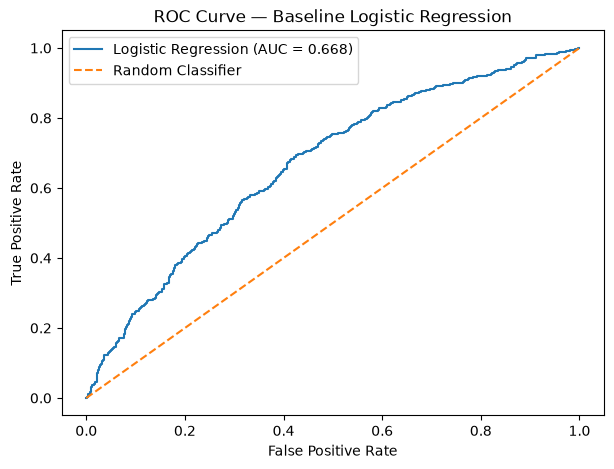

In [315]:
plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Baseline Logistic Regression")
plt.legend()

plt.show()

# Part F — Model Interpretation and Limitations

In [316]:
feature_names = (
    baseline_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

In [317]:
coefficients = (
    baseline_model
    .named_steps["classifier"]
    .coef_[0]
)

In [318]:
coefficient_table = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coefficient_table["Absolute_Coefficient"] = (
    coefficient_table["Coefficient"].abs()
)

In [319]:
coefficient_table_sorted = (
    coefficient_table
    .sort_values(
        "Absolute_Coefficient",
        ascending=False
    )
)

coefficient_table_sorted.head(15)

,Feature,Coefficient,Absolute_Coefficient
13,cat__Transaction_Type_Transfer,0.453731,0.453731
11,cat__Transaction_Type_Cash Withdrawal,0.416544,0.416544
12,cat__Transaction_Type_Deposit,-0.408652,0.408652
10,cat__Transaction_Type_Card Purchase,-0.406993,0.406993
9,cat__Transaction_Type_Bill Payment,-0.401575,0.401575
21,cat__Device_Type_Missing,-0.398595,0.398595
32,cat__Location_Missing,-0.382848,0.382848
38,cat__Account_Type_Current,-0.284523,0.284523
48,cat__Preferred_Channel_Web,-0.258476,0.258476
4,num__Transaction_Hour,-0.256259,0.256259
